In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
aadigupta1601_f1_strategy_dataset_pit_stop_prediction_path = kagglehub.dataset_download('aadigupta1601/f1-strategy-dataset-pit-stop-prediction')

print('Data source import complete.')


100%|██████████| 2.59M/2.59M [00:01<00:00, 1.42MB/s]

Extracting files...


Data source import complete.


In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Original Shape: (101371, 16)
⚠️ Using CPU
[0]	validation_0-logloss:0.47993
[50]	validation_0-logloss:0.30831
[100]	validation_0-logloss:0.25127
[150]	validation_0-logloss:0.22537
[200]	validation_0-logloss:0.20799
[250]	validation_0-logloss:0.20510
[300]	validation_0-logloss:0.19745
[350]	validation_0-logloss:0.19728
[400]	validation_0-logloss:0.19452
[450]	validation_0-logloss:0.19098
[500]	validation_0-logloss:0.19167
[550]	validation_0-logloss:0.19442
[600]	validation_0-logloss:0.19341
[650]	validation_0-logloss:0.19400
[700]	validation_0-logloss:0.19443
[750]	validation_0-logloss:0.19570
[800]	validation_0-logloss:0.19673
[850]	validation_0-logloss:0.19827
[900]	validation_0-logloss:0.20029
[950]	validation_0-logloss:0.20086
[999]	validation_0-logloss:0.20219

🎯 FINAL RESULTS (REALISTIC)
Accuracy : 0.9475395360038532
Precision: 0.3141831238779174
Recall   : 0.7653061224489796
F1 Score : 0.4454815443360204


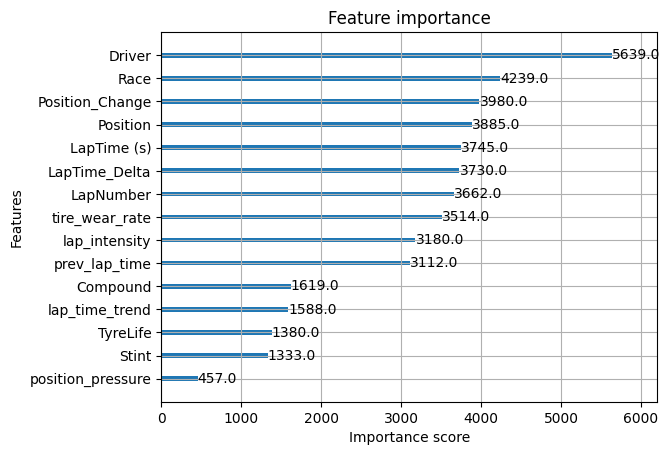

In [11]:
# import pandas as pd
# import numpy as np
# import os

# from sklearn.preprocessing import LabelEncoder
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
# from sklearn.model_selection import train_test_split

# import xgboost as xgb

# # =========================
# # 1. LOAD DATA
# # =========================
# df = pd.read_csv(os.path.join(
#     aadigupta1601_f1_strategy_dataset_pit_stop_prediction_path,
#     "f1_strategy_dataset_v4.csv"
# ))

# print("Original Shape:", df.shape)

# # =========================
# # 2. TARGET
# # =========================
# target = "PitStop"
# df[target] = df[target].astype(int)

# # =========================
# # 3. REMOVE LEAKAGE ❌
# # =========================
# leak_cols = [
#     "PitNextLap",
#     "RaceProgress",
#     "Normalized_TyreLife",
#     "Cumulative_Degradation"
# ]

# df = df.drop(columns=[c for c in leak_cols if c in df.columns])

# # =========================
# # 4. FEATURE ENGINEERING 🔥
# # =========================
# df["tire_wear_rate"] = df["TyreLife"] / (df["LapNumber"] + 1)
# df["lap_intensity"] = df["LapTime_Delta"] / (df["LapTime (s)"] + 1)
# df["position_pressure"] = df["Position"] / 20

# # temporal features
# df["prev_lap_time"] = df.groupby("Driver")["LapTime (s)"].shift(1)
# df["lap_time_trend"] = df["LapTime (s)"] - df["prev_lap_time"]
# df["lap_time_trend"] = df["lap_time_trend"].fillna(0)

# # =========================
# # 5. ENCODE CATEGORICAL
# # =========================
# le_dict = {}
# for col in df.select_dtypes(include='object').columns:
#     le = LabelEncoder()
#     df[col] = le.fit_transform(df[col])
#     le_dict[col] = le

# # =========================
# # 6. TIME-BASED SPLIT
# # =========================
# train_df = df[df["Year"] < 2023]
# test_df  = df[df["Year"] == 2023]

# if len(test_df) == 0:
#     train_df, test_df = train_test_split(df, test_size=0.2, stratify=df[target], random_state=42)

# X_train = train_df.drop(columns=[target])
# y_train = train_df[target]

# X_test = test_df.drop(columns=[target])
# y_test = test_df[target]

# # =========================
# # 7. CLASS IMBALANCE FIX ⚖️
# # =========================
# neg = len(y_train[y_train == 0])
# pos = len(y_train[y_train == 1])

# scale_pos_weight = (neg / pos) * 0.6  # tuned (IMPORTANT)

# # =========================
# # 8. GPU AUTO DETECT ⚡
# # =========================
# tree_method = "hist"

# try:
#     import torch
#     if torch.cuda.is_available():
#         tree_method = "gpu_hist"
#         print("✅ Using GPU")
#     else:
#         print("⚠️ Using CPU")
# except:
#     print("⚠️ Torch not found, using CPU")

# # =========================
# # 9. MODEL
# # =========================
# model = xgb.XGBClassifier(
#     objective='binary:logistic', # Added objective for binary classification
#     tree_method=tree_method,
#     n_estimators=1000,
#     max_depth=6,
#     learning_rate=0.04,
#     subsample=0.9,
#     colsample_bytree=0.9,
#     scale_pos_weight=scale_pos_weight,
#     eval_metric="logloss",
#     random_state=42
# )

# # =========================
# # 10. TRAIN WITH EARLY STOP (FIXED)
# # =========================
# # Removed: from xgboost.callback import EarlyStopping

# model.fit(
#     X_train, y_train,
#     eval_set=[(X_test, y_test)],
#     verbose=50
#     # Removed: early_stopping_rounds=50 # Changed from callbacks to early_stopping_rounds
#     # Removed: callbacks=[EarlyStopping(rounds=50, save_best=True)]
# )

# # =========================
# # 11. SMART PREDICTION 🎯
# # =========================
# y_prob = model.predict_proba(X_test)[:, 1]

# # 🔥 tune this for best balance
# threshold = 0.7

# y_pred = (y_prob > threshold).astype(int)

# # =========================
# # 12. FINAL METRICS
# # =========================
# print("\n🎯 FINAL RESULTS (REALISTIC)")
# print("Accuracy :", accuracy_score(y_test, y_pred))
# print("Precision:", precision_score(y_test, y_pred))
# print("Recall   :", recall_score(y_test, y_pred))
# print("F1 Score :", f1_score(y_test, y_pred))

# # =========================
# # 13. FEATURE IMPORTANCE
# # =========================
# import matplotlib.pyplot as plt

# xgb.plot_importance(model, max_num_features=15)
# plt.show()

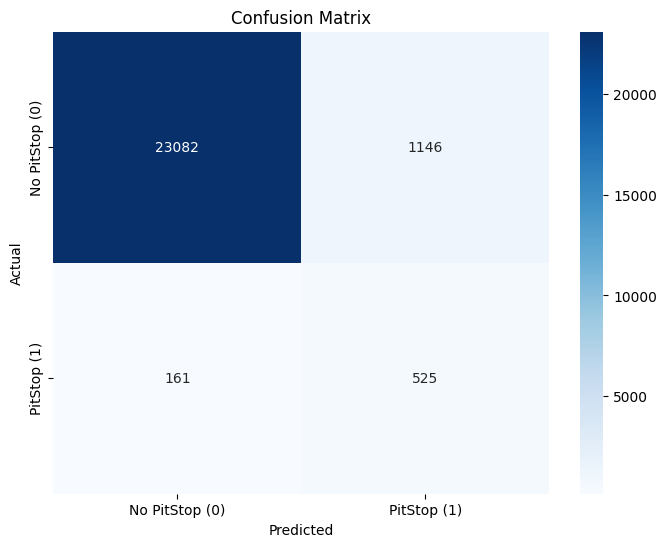

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No PitStop (0)', 'PitStop (1)'],
            yticklabels=['No PitStop (0)', 'PitStop (1)'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

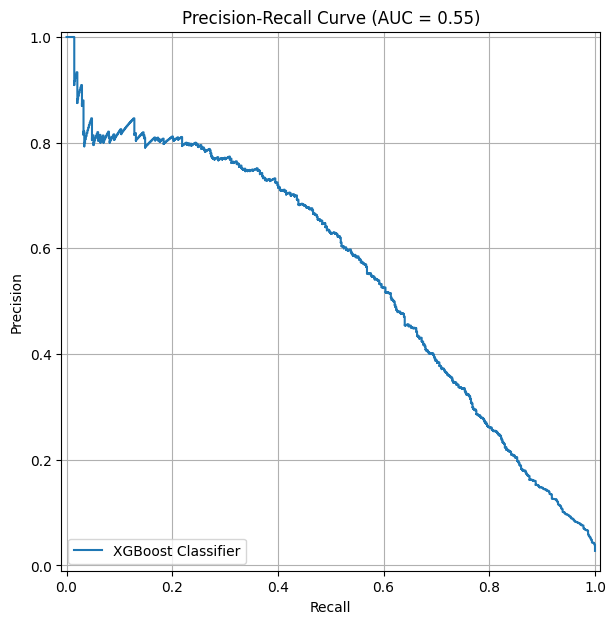

Best Threshold (maximizing F1-score): 0.8972
Precision at best threshold: 0.5695
Recall at best threshold: 0.5671
F1-score at best threshold: 0.5683


In [13]:
from sklearn.metrics import precision_recall_curve, auc, PrecisionRecallDisplay
import matplotlib.pyplot as plt

# Calculate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Calculate Area Under the Curve (AUC) for the PR curve
pr_auc = auc(recall, precision)

# Plot the Precision-Recall curve
plt.figure(figsize=(10, 7))
PrecisionRecallDisplay(precision=precision, recall=recall, estimator_name='XGBoost Classifier').plot(ax=plt.gca())
plt.title(f'Precision-Recall Curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)
plt.show()

# Find the threshold that maximizes the F1-score (a common approach)
fscore = (2 * precision * recall) / (precision + recall)
ix = np.argmax(fscore)
optimal_threshold = thresholds[ix]

print(f'Best Threshold (maximizing F1-score): {optimal_threshold:.4f}')
print(f'Precision at best threshold: {precision[ix]:.4f}')
print(f'Recall at best threshold: {recall[ix]:.4f}')
print(f'F1-score at best threshold: {fscore[ix]:.4f}')

Original Shape: (101371, 16)
⚠️ Using CPU
[0]	validation_0-logloss:0.42743
[50]	validation_0-logloss:0.28759
[100]	validation_0-logloss:0.22899
[150]	validation_0-logloss:0.20513
[200]	validation_0-logloss:0.19307
[250]	validation_0-logloss:0.18782
[300]	validation_0-logloss:0.18750
[350]	validation_0-logloss:0.18542
[400]	validation_0-logloss:0.18452
[450]	validation_0-logloss:0.18556
[500]	validation_0-logloss:0.18543
[550]	validation_0-logloss:0.18655
[600]	validation_0-logloss:0.18705
[650]	validation_0-logloss:0.18850
[700]	validation_0-logloss:0.18951
[750]	validation_0-logloss:0.19119
[799]	validation_0-logloss:0.19234

🔥 BEST THRESHOLD: 0.8976
Precision: 0.6650
Recall   : 0.5700
F1 Score : 0.6138

🎯 FINAL RESULTS
Accuracy : 0.9802119290358834
Precision: 0.6643952299829642
Recall   : 0.5685131195335277
F1 Score : 0.612725844461901


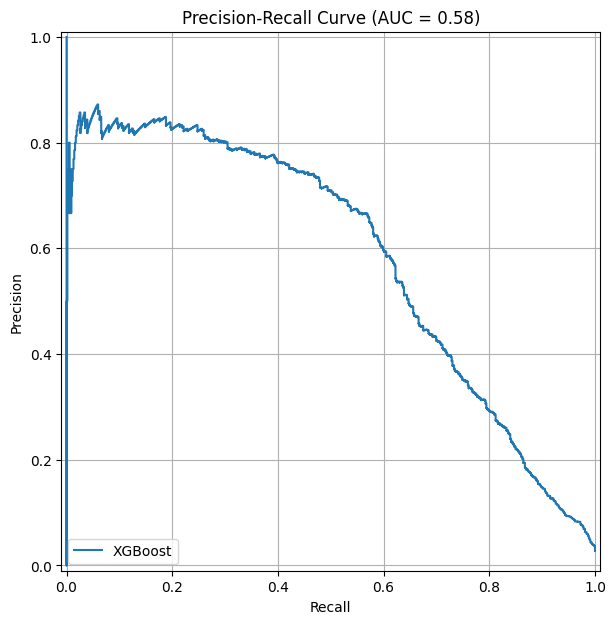

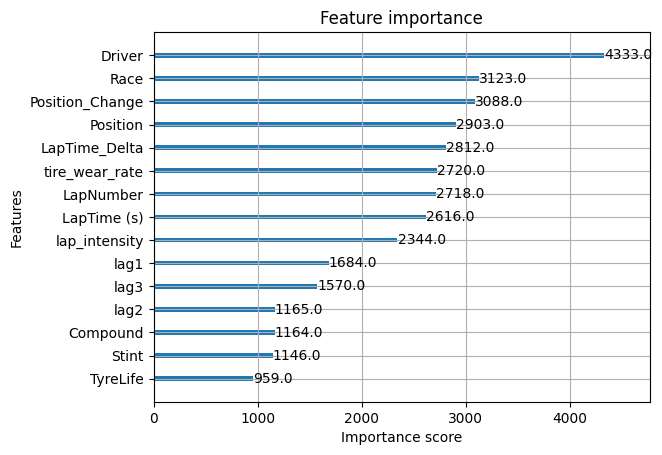

In [16]:
import pandas as pd
import numpy as np
import os

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    precision_recall_curve, auc, PrecisionRecallDisplay
)
from sklearn.model_selection import train_test_split

import xgboost as xgb
import matplotlib.pyplot as plt

# =========================
# 1. LOAD DATA
# =========================
df = pd.read_csv(os.path.join(
    aadigupta1601_f1_strategy_dataset_pit_stop_prediction_path,
    "f1_strategy_dataset_v4.csv"
))

print("Original Shape:", df.shape)

# =========================
# 2. TARGET
# =========================
target = "PitStop"
df[target] = df[target].astype(int)

# =========================
# 3. REMOVE LEAKAGE ❌
# =========================
leak_cols = [
    "PitNextLap",
    "RaceProgress",
    "Normalized_TyreLife",
    "Cumulative_Degradation"
]
df = df.drop(columns=[c for c in leak_cols if c in df.columns])

# =========================
# 4. FEATURE ENGINEERING 🔥
# =========================
df["tire_wear_rate"] = df["TyreLife"] / (df["LapNumber"] + 1)
df["lap_intensity"] = df["LapTime_Delta"] / (df["LapTime (s)"] + 1)
df["position_pressure"] = df["Position"] / 20

# Temporal features (sequence awareness)
df["lag1"] = df.groupby("Driver")["LapTime (s)"].shift(1)
df["lag2"] = df.groupby("Driver")["LapTime (s)"].shift(2)
df["lag3"] = df.groupby("Driver")["LapTime (s)"].shift(3)

df["lap_trend"] = df["lag1"] - df["lag2"]
# Handling NaNs in numerical columns before feature engineering
# For categorical columns, NaNs should be handled before encoding, or filled with strings.
# Let's ensure categorical columns are handled correctly before fillna(0) for numericals

# =========================
# 5. ENCODE CATEGORICAL
# =========================
le_dict = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    # Convert column to string type before encoding to avoid mixed types due to NaNs
    df[col] = df[col].astype(str).fillna('Missing') # Fill NaNs with a string for object columns
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

# Now fill any remaining numerical NaNs with 0 (after categorical encoding)
df = df.fillna(0)

# =========================
# 6. TIME-BASED SPLIT
# =========================
train_df = df[df["Year"] < 2023]
test_df  = df[df["Year"] == 2023]

if len(test_df) == 0:
    train_df, test_df = train_test_split(
        df, test_size=0.2, stratify=df[target], random_state=42
    )

X_train = train_df.drop(columns=[target])
y_train = train_df[target]

X_test = test_df.drop(columns=[target])
y_test = test_df[target]

# =========================
# 7. CLASS IMBALANCE ⚖️
# =========================
neg = len(y_train[y_train == 0])
pos = len(y_train[y_train == 1])
scale_pos_weight = (neg / pos) * 0.5

# =========================
# 8. GPU AUTO DETECT ⚡
# =========================
tree_method = "hist"

try:
    import torch
    if torch.cuda.is_available():
        tree_method = "gpu_hist"
        print("✅ Using GPU")
    else:
        print("⚠️ Using CPU")
except:
    print("⚠️ Torch not found, using CPU")

# =========================
# 9. MODEL
# =========================
model = xgb.XGBClassifier(
    objective='binary:logistic',
    tree_method=tree_method,
    n_estimators=800,
    max_depth=6,
    learning_rate=0.04,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)

# =========================
# 10. TRAIN
# =========================
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

# =========================
# 11. PREDICTIONS
# =========================
y_prob = model.predict_proba(X_test)[:, 1]

# =========================
# 12. AUTO THRESHOLD 🔥
# =========================
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

f1_scores = (2 * precision * recall) / (precision + recall + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"\n🔥 BEST THRESHOLD: {best_threshold:.4f}")
print(f"Precision: {precision[best_idx]:.4f}")
print(f"Recall   : {recall[best_idx]:.4f}")
print(f"F1 Score : {f1_scores[best_idx]:.4f}")

# Apply threshold
y_pred = (y_prob > best_threshold).astype(int)

# =========================
# 13. FINAL METRICS 🎯
# =========================
print("\n🎯 FINAL RESULTS")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

# =========================
# 14. PR CURVE 📊
# =========================
pr_auc = auc(recall, precision)

plt.figure(figsize=(10, 7))
PrecisionRecallDisplay(
    precision=precision,
    recall=recall,
    estimator_name='XGBoost'
).plot(ax=plt.gca())

plt.title(f'Precision-Recall Curve (AUC = {pr_auc:.2f})')
plt.grid(True)
plt.show()

# =========================
# 15. FEATURE IMPORTANCE
# =========================
xgb.plot_importance(model, max_num_features=15)
plt.show()

In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     24228
           1       0.66      0.57      0.61       686

    accuracy                           0.98     24914
   macro avg       0.83      0.78      0.80     24914
weighted avg       0.98      0.98      0.98     24914



In [18]:
from sklearn.metrics import balanced_accuracy_score

print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))

Balanced Accuracy: 0.7801910157680847


In [19]:
model.save_model("f1_pitstop_model.json")